In [ ]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
# Load the Dataset
df = pd.read_csv('/content/Personal_Finance_Dataset.csv')

print("Dataset Loaded Successfully!")



Dataset Loaded Successfully!


In [ ]:
print("Shape:", df.shape)

Shape: (1500, 5)


In [ ]:
df.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [ ]:
# Check basic info
print(df.info())
print("\nUnique Categories:", df['Category'].unique())
print("\nUnique Types:", df['Type'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   object 
 1   Transaction Description  1500 non-null   object 
 2   Category                 1500 non-null   object 
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   object 
dtypes: float64(1), object(4)
memory usage: 58.7+ KB
None

Unique Categories: ['Food & Drink' 'Utilities' 'Rent' 'Investment' 'Shopping' 'Other'
 'Entertainment' 'Health & Fitness' 'Salary' 'Travel']

Unique Types: ['Expense' 'Income']


In [ ]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month and Year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print("Date Cleaned Successfully!")
print(df[['Date', 'Month', 'Year']].head())

Date Cleaned Successfully!
        Date  Month  Year
0 2020-01-02      1  2020
1 2020-01-02      1  2020
2 2020-01-04      1  2020
3 2020-01-05      1  2020
4 2020-01-13      1  2020


/tmp/ipykernel_653/973978672.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_summary.index, y=type_summary.values, palette='Set2')


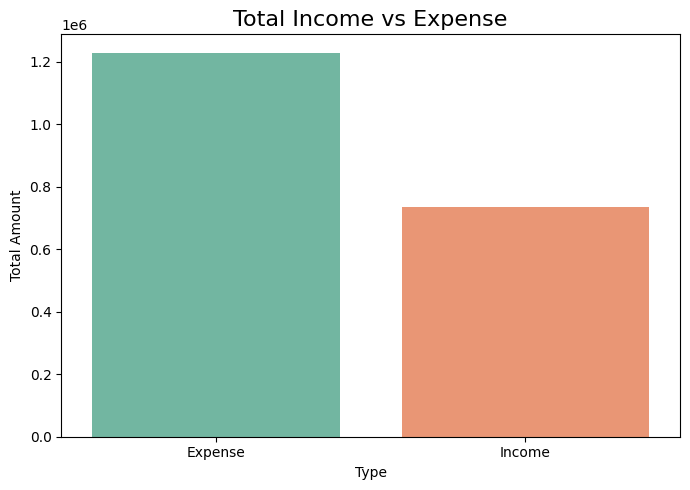

Type
Expense    1227194.37
Income      734087.00
Name: Amount, dtype: float64


In [ ]:
# Expense vs Income Total
type_summary = df.groupby('Type')['Amount'].sum()

plt.figure(figsize=(7, 5))
sns.barplot(x=type_summary.index, y=type_summary.values, palette='Set2')
plt.title('Total Income vs Expense', fontsize=16)
plt.xlabel('Type')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

print(type_summary)

/tmp/ipykernel_653/661148441.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_expense.index, y=category_expense.values, palette='viridis')


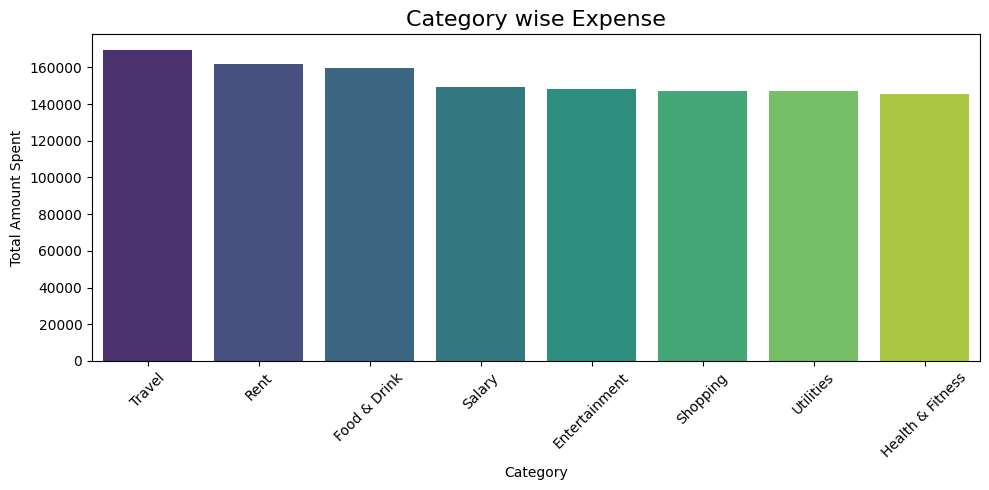

In [ ]:
# Category wise Expense
expense_df = df[df['Type'] == 'Expense']
category_expense = expense_df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=category_expense.index, y=category_expense.values, palette='viridis')
plt.title('Category wise Expense', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

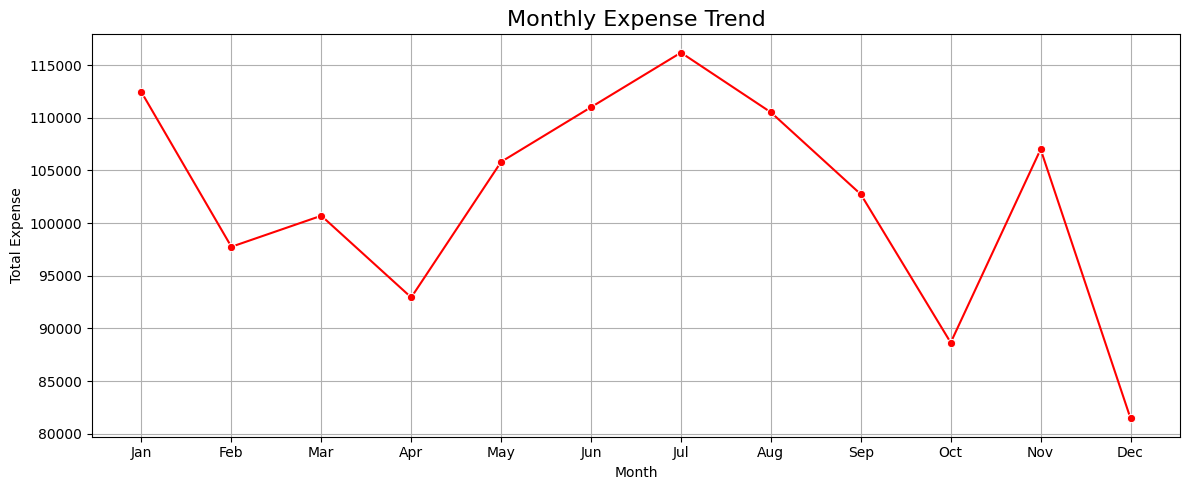

In [ ]:
# Monthly Expense Trend
monthly_expense = expense_df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_expense.index, y=monthly_expense.values, marker='o', color='red')
plt.title('Monthly Expense Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Expense')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

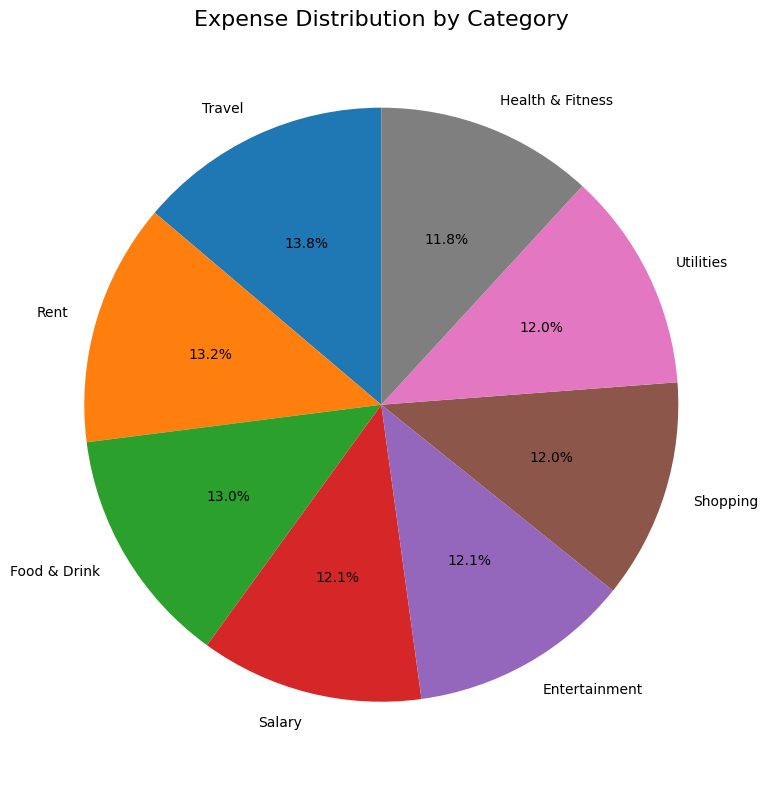

In [ ]:
# Expense Distribution Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(category_expense.values, labels=category_expense.index, autopct='%1.1f%%', startangle=90)
plt.title('Expense Distribution by Category', fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
# Project Summary
print("=" * 55)
print("   PERSONAL EXPENSE ANALYTICS - SUMMARY")
print("=" * 55)
print(f"Total Transactions: {df.shape[0]}")
print(f"Total Income: ${df[df['Type']=='Income']['Amount'].sum():,.2f}")
print(f"Total Expense: ${df[df['Type']=='Expense']['Amount'].sum():,.2f}")
print(f"Net Savings: ${df[df['Type']=='Income']['Amount'].sum() - df[df['Type']=='Expense']['Amount'].sum():,.2f}")
print(f"Highest Expense Category: Travel")
print(f"Highest Expense Month: July")
print(f"Lowest Expense Month: December")
print("=" * 55)
print("Project Completed Successfully! ")

   PERSONAL EXPENSE ANALYTICS - SUMMARY
Total Transactions: 1500
Total Income: $734,087.00
Total Expense: $1,227,194.37
Net Savings: $-493,107.37
Highest Expense Category: Travel
Highest Expense Month: July
Lowest Expense Month: December
Project Completed Successfully! 
